# Import Data

In [87]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [88]:
cleaned_data = "../../data/spotify_charts_2019_2023_cleaned.csv"
df = pd.read_csv(cleaned_data, dtype={11: 'boolean'})
df.head()

,title,rank,date,artist,region,chart,trend,streams,album_name,popularity,...,af_key,af_loudness,af_mode,af_speechiness,af_acousticness,af_instrumentalness,af_liveness,af_valence,af_tempo,af_time_signature
0,Ride It,146,2020-05-01,Regard,Bolivia,top200,MOVE_UP,1956.0,Ride It,81.0,...,7.0,-4.258,0.0,0.0874,0.1770,0.000064,0.1060,0.884,117.948,4.0
1,+Linda,147,2020-05-01,Dalex,Bolivia,top200,MOVE_DOWN,1953.0,+Linda,63.0,...,9.0,-5.501,1.0,0.3400,0.1310,0.000000,0.1300,0.396,175.896,4.0
2,Woah,148,2020-05-01,Lil Baby,Canada,top200,MOVE_UP,35211.0,My Turn,67.0,...,11.0,-5.551,1.0,0.2480,0.0177,0.000000,0.1790,0.413,142.976,4.0
3,25/8,105,2020-05-01,Bad Bunny,Chile,top200,MOVE_DOWN,31854.0,YHLQMDLG,70.0,...,4.0,-5.469,0.0,0.0549,0.0920,0.000000,0.0716,0.542,151.982,4.0
4,Keii,65,2020-05-01,Anuel AA,Colombia,top200,MOVE_UP,16155.0,Keii,66.0,...,0.0,-3.095,0.0,0.0391,0.4000,0.000000,0.0960,0.510,88.015,4.0


# Cleaning

In [89]:
df.shape

(16909377, 25)

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16909377 entries, 0 to 16909376
Data columns (total 25 columns):
 #   Column               Dtype  
---  ------               -----  
 0   title                str    
 1   rank                 int64  
 2   date                 str    
 3   artist               str    
 4   region               str    
 5   chart                str    
 6   trend                str    
 7   streams              float64
 8   album_name           str    
 9   popularity           float64
 10  duration_ms          float64
 11  explicit             boolean
 12  release_date         str    
 13  af_danceability      float64
 14  af_energy            float64
 15  af_key               float64
 16  af_loudness          float64
 17  af_mode              float64
 18  af_speechiness       float64
 19  af_acousticness      float64
 20  af_instrumentalness  float64
 21  af_liveness          float64
 22  af_valence           float64
 23  af_tempo             float64
 24  af_time

Make date columns of type `datetime` instead of `str`, and downcast numbers to 32b improve memory performance.

In [91]:
df['date'] = pd.to_datetime(df['date'])
df['release_date'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce')

for col in df.columns:
    col_type = df[col].dtype

    # Downcast floats
    if col_type == 'float64':
        df[col] = pd.to_numeric(df[col], downcast='float')

    # Downcast integers
    elif col_type == 'int64':
        df[col] = pd.to_numeric(df[col], downcast='integer')

In [92]:
df_summary = df.describe(include='all')
df_summary

,title,rank,date,artist,region,chart,trend,streams,album_name,popularity,...,af_key,af_loudness,af_mode,af_speechiness,af_acousticness,af_instrumentalness,af_liveness,af_valence,af_tempo,af_time_signature
count,16909366,1.690938e+07,16909377,16909359,16909377,16909377,16909377,1.319607e+07,16650814,1.666908e+07,...,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07,1.666908e+07
unique,100435,NaN,NaN,58927,70,2,4,NaN,70184,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Dance Monkey,NaN,NaN,Billie Eilish,Austria,top200,MOVE_DOWN,NaN,YHLQMDLG,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,56850,NaN,NaN,229470,273534,13196070,7301805,NaN,106812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,8.199409e+01,2020-07-06 03:49:09.924626,NaN,NaN,NaN,NaN,5.632970e+04,NaN,5.144748e+01,...,5.390780e+00,-6.360574e+00,5.661959e-01,1.134851e-01,2.739324e-01,1.445684e-02,1.698822e-01,5.305176e-01,1.218442e+02,3.964322e+00
min,NaN,1.000000e+00,2019-01-01 00:00:00,NaN,NaN,NaN,NaN,1.001000e+03,NaN,0.000000e+00,...,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,3.000000e+01,2019-10-15 00:00:00,NaN,NaN,NaN,NaN,3.741000e+03,NaN,3.500000e+01,...,2.000000e+00,-7.646000e+00,0.000000e+00,4.270000e-02,6.310000e-02,0.000000e+00,9.330000e-02,3.550000e-01,9.701400e+01,4.000000e+00
50%,NaN,6.900000e+01,2020-07-16 00:00:00,NaN,NaN,NaN,NaN,9.785000e+03,NaN,6.100000e+01,...,6.000000e+00,-5.982000e+00,1.000000e+00,6.940000e-02,1.920000e-01,0.000000e+00,1.190000e-01,5.350000e-01,1.199680e+02,4.000000e+00
75%,NaN,1.330000e+02,2021-03-31 00:00:00,NaN,NaN,NaN,NaN,3.749400e+04,NaN,7.400000e+01,...,8.000000e+00,-4.593000e+00,1.000000e+00,1.480000e-01,4.230000e-01,3.140000e-05,1.990000e-01,7.030000e-01,1.405190e+02,4.000000e+00
max,NaN,2.000000e+02,2021-12-31 00:00:00,NaN,NaN,NaN,NaN,1.974970e+07,NaN,9.600000e+01,...,1.100000e+01,2.240000e+00,1.000000e+00,9.650000e-01,9.960000e-01,9.930000e-01,9.910000e-01,9.990000e-01,2.384310e+02,5.000000e+00


# Exploratory Analysis
To make EDA run more efficiently, we take a random sample of 500k values (3% of the whole dataset)

In [93]:
SEED = 42
eda_summary = df.sample(n=500_000, random_state=SEED)
eda_summary.describe()

,rank,date,streams,popularity,duration_ms,release_date,af_danceability,af_energy,af_key,af_loudness,af_mode,af_speechiness,af_acousticness,af_instrumentalness,af_liveness,af_valence,af_tempo,af_time_signature
count,500000.000000,500000,3.901910e+05,492889.000000,4.928890e+05,492889,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000,492889.000000
mean,82.093024,2020-07-05 15:55:32.448000,5.663201e+04,51.412338,2.050878e+05,2016-06-16 15:39:38.967272,0.689814,0.634623,5.390392,-6.357976,0.565539,0.113614,0.273796,0.014497,0.170033,0.530718,121.942017,3.964162
min,1.000000,2019-01-01 00:00:00,1.001000e+03,0.000000,0.000000e+00,0000-01-01 00:00:00,0.071000,0.000065,0.000000,-38.782001,0.000000,0.022000,0.000001,0.000000,0.013400,0.000000,31.261999,1.000000
25%,30.000000,2019-10-15 00:00:00,3.752000e+03,35.000000,1.749330e+05,2018-12-21 00:00:00,0.603000,0.525000,2.000000,-7.643000,0.000000,0.042700,0.063200,0.000000,0.093200,0.355000,97.017998,4.000000
50%,69.000000,2020-07-15 00:00:00,9.813000e+03,61.000000,1.999310e+05,2019-10-04 00:00:00,0.711000,0.652000,6.000000,-5.980000,1.000000,0.069500,0.192000,0.000000,0.119000,0.535000,119.968002,4.000000
75%,133.000000,2021-03-30 00:00:00,3.745450e+04,74.000000,2.267460e+05,2020-07-24 00:00:00,0.791000,0.758000,8.000000,-4.596000,1.000000,0.148000,0.423000,0.000031,0.200000,0.703000,141.020004,4.000000
max,200.000000,2021-12-31 00:00:00,9.451738e+06,96.000000,6.011575e+06,2023-10-05 00:00:00,0.987000,1.000000,11.000000,2.240000,1.000000,0.957000,0.996000,0.985000,0.990000,0.995000,233.871994,5.000000
std,59.440310,NaN,2.120494e+05,28.646852,5.154239e+04,NaN,0.138562,0.166141,3.630842,2.568063,0.495687,0.102959,0.251395,0.088528,0.131526,0.222890,29.857761,0.292768


Raw streams is significantly skewed to the right with most streams being less than 1M. However, there are some outliers that were extremely successful, hitting nearly 1B streams. When looking closer at the majority of streams, there are two peaks around 8.1k and 36.3k streams.

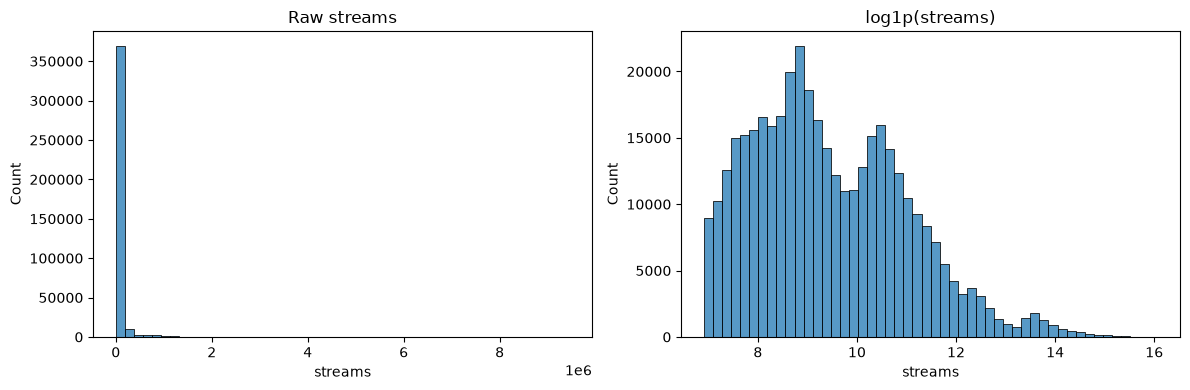

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# raw distribution
sns.histplot(eda_summary['streams'], bins=50, ax=axes[0])
axes[0].set_title('Raw streams')

# log-transformed distribution
sns.histplot(np.log1p(eda_summary['streams']), bins=50, ax=axes[1])
axes[1].set_title('log1p(streams)')

plt.tight_layout()
plt.show()

### Top 200 vs Viral 50 Chart

When looking into the possible causes of these two peaks, we explore the two charts. Perhaps the Viral 50 Chart has less streams since those songs more likely to be quick fads. However, in discovery, it's found that Viral 50 *does not* contribute to streams, which is are target label.

With Viral 50 only making up ~21% of the data, and given our large dataset (16M observations), we can safely cut the column observe songs only in the Top 200 Chart.

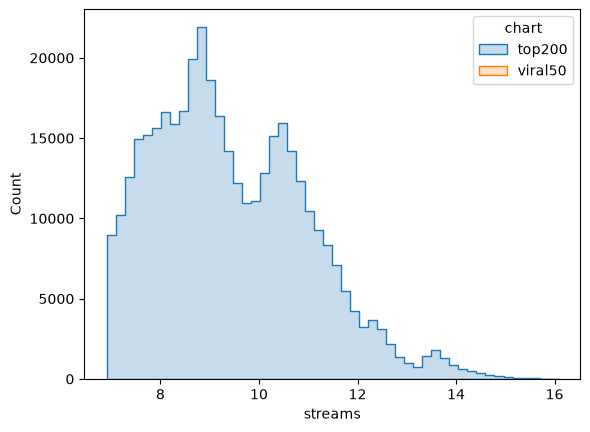

In [95]:
# by chart type
sns.histplot(data=eda_summary, x=np.log1p(eda_summary['streams']), hue='chart', bins=50, element='step')
plt.show()

In [96]:
eda_summary['chart'].value_counts(normalize=True)

chart
top200     0.780382
viral50    0.219618
Name: proportion, dtype: float64

In [97]:
df.groupby('chart')['streams'].agg(['count', 'isna_sum' if False else 'size', lambda x: x.isna().sum(), 'mean', 'median'])

,count,size,<lambda_0>,mean,median
chart,,,,,
top200,13196070,13196070,0,56329.703194,9785.0
viral50,0,3713307,3713307,NaN,NaN


Viral 50 has no record of streams, confirming it is safe to remove.

In [98]:
df[df['chart']=='viral50']['streams'].isna().mean()

np.float64(1.0)

In [99]:
df = df[df['chart'] == 'top200']

eda_summary = df.sample(n=500_000, random_state=SEED)
eda_summary['chart'].value_counts(normalize=True)

chart
top200    1.0
Name: proportion, dtype: float64

## Streams by Region

There are 70 unique regions in this dataset. To simply, if we bucket them into continents, splitting North and South America.

The Global "Continent" dominates the median streams per continent. However, this could simply be from where the top 200 charts come from (i.e. which chart the song is listed in). Therefore, region/continent may not be the most reliable feature.

In [100]:
import country_converter as coco

cc = coco.CountryConverter()
unique_regions = df.loc[df['region'] != 'Global', 'region'].unique()
un_regions = dict(zip(unique_regions, cc.convert(names=unique_regions, to="UNregion")))
un_regions['Global'] = 'Global'

un_to_continent_split = {
    'Australia and New Zealand': 'Oceania',
    'Caribbean': 'North America',
    'Central America': 'North America',
    'Eastern Asia': 'Asia',
    'Eastern Europe': 'Europe',
    'Global': 'Global',
    'Northern Africa': 'Africa',
    'Northern America': 'North America',
    'Northern Europe': 'Europe',
    'South America': 'South America',
    'South-eastern Asia': 'Asia',
    'Southern Africa': 'Africa',
    'Southern Asia': 'Asia',
    'Southern Europe': 'Europe',
    'Western Asia': 'Asia',
    'Western Europe': 'Europe',
}

df['continent'] = df['region'].map(un_regions).map(un_to_continent_split)
eda_summary['continent'] = eda_summary['region'].map(un_regions).map(un_to_continent_split)

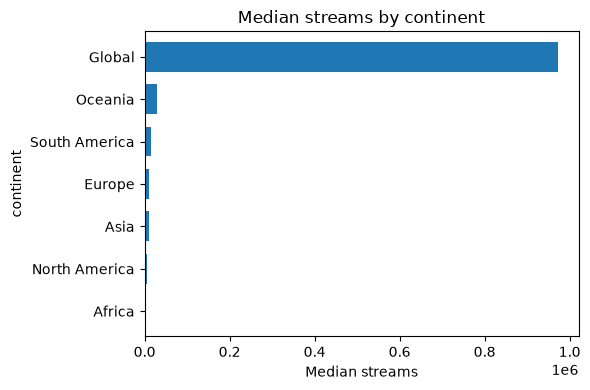

In [101]:
continent_medians = eda_summary.groupby('continent')['streams'].median().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
continent_medians.plot(kind='barh', width=0.7)
plt.xlabel('Median streams')
plt.title('Median streams by continent')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Audio Feature Correlation

None of the audio features seem to be redundant, as each have only low or moderate correlation with each other. Additionally, each feature has low correlation with streams, suggesting there may be a non-linear relationship between these features. They are candidate features, but should not be expected to be driving.

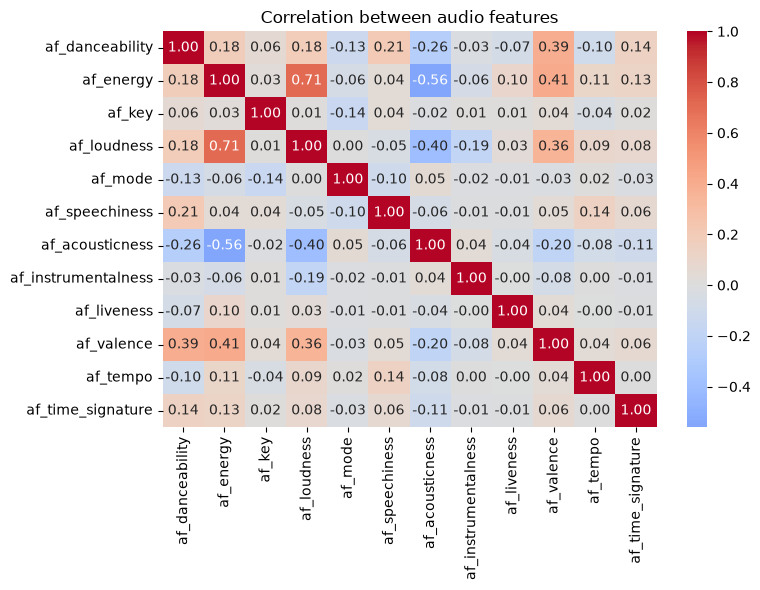

In [102]:
af_columns = [col for col in eda_summary.columns if col.startswith("af_")]
corr = eda_summary[af_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between audio features')
plt.tight_layout()
plt.show()

In [103]:
eda_summary[af_columns + ['streams']].corr()['streams'].sort_values()

af_acousticness       -0.006216
af_energy             -0.005202
af_instrumentalness   -0.003308
af_valence            -0.000028
af_key                -0.000020
af_time_signature      0.000811
af_mode                0.001238
af_loudness            0.006987
af_tempo               0.007819
af_danceability        0.009865
af_speechiness         0.009989
af_liveness            0.012619
streams                1.000000
Name: streams, dtype: float64

# Streams vs Popularity

Surprisingly, the distribution between streams and popularity has a small hump (weakly normal). The correlation between popularity and streams is only 1.45%, meaning that there is no linear relationship between the two. We can assume that there will be no leakage among this feature and label.

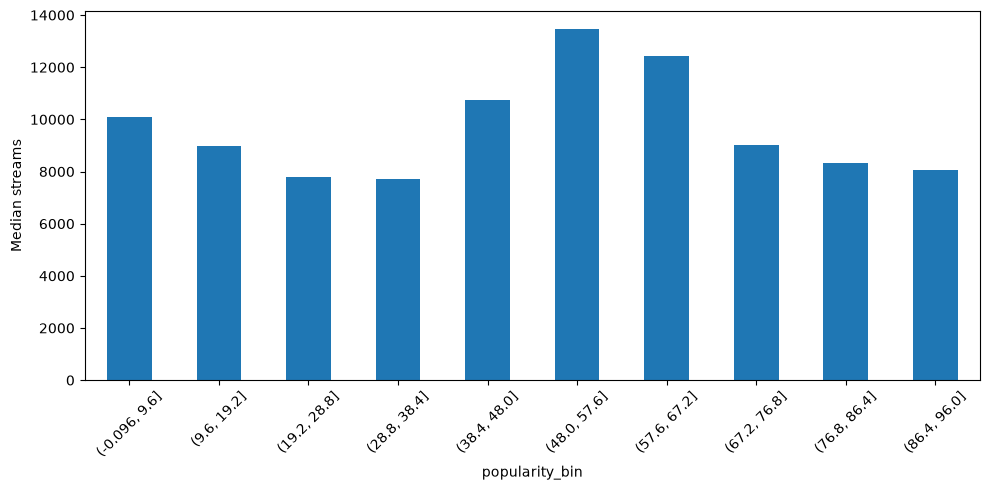

In [104]:
eda_summary['popularity_bin'] = pd.cut(eda_summary['popularity'], bins=10)
binned = eda_summary.groupby('popularity_bin')['streams'].median()

binned.plot(kind='bar', figsize=(10,5))
plt.ylabel('Median streams')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [105]:
correlation = float(eda_summary['popularity'].corr(np.log1p(eda_summary['streams']))) * 100
print("Correlation between Popularity and Streams:", round(correlation, 2), "%")

Correlation between Popularity and Streams: 1.45 %


# Export DataFrame

In [106]:
df.to_csv("../../data/spotify_charts_2019_2023_cleaned_v2.csv", index=False)